# **Estimation of (Non)-Survival in the Titanic Dataset using Machine Learning Models**

### import libraries

In [1]:
!pip install lazypredict

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, classification_report, plot_roc_curve
from sklearn.model_selection import train_test_split, cross_validate, validation_curve, GridSearchCV
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from lazypredict.Supervised import LazyClassifier
from lightgbm import LGBMClassifier
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.float_format', lambda x: '%.3f' %x)

### import dataset

In [3]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')

train.head()
test.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.500,0,0,330911,7.829,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.000,1,0,363272,7.000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.000,0,0,240276,9.688,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.000,0,0,315154,8.662,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.000,1,1,3101298,12.287,NaN,S


In [4]:
df_survived = train[['Survived']]
train = train.drop(['Survived'], axis=1)
train.shape, test.shape, df_survived.shape
df = pd.concat([train, test], ignore_index=True)
df.shape
df.head()

((891, 11), (418, 11), (891, 1))

(1309, 11)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


# Exploratory Data Analysis

### check dataframe

In [5]:
def check_dataframe(dataframe, head=5):
    print('\n', '#' * 20, 'head'.upper(), 20 * '#')
    display(dataframe.head(head))
    print('\n', '#' * 20, 'tail'.upper(), 20 * '#')
    display(dataframe.tail(head))
    print('\n', '#' * 20, 'shape'.upper(), 20 * '#')
    print(dataframe.shape)
    print('\n', '#' * 20, 'dtypes'.upper(), 20 * '#')
    print(dataframe.dtypes)
    print('\n', '#' * 20, 'columns'.upper(), 20 * '#')
    print(dataframe.columns)
    print('\n', '#' * 20, 'info'.upper(), 20 * '#')
    print(dataframe.info())
    print('\n', '#' * 20, 'any null values'.upper(), 20 * '#')
    print(dataframe.isnull().values.any())
    print('\n', '#' * 20, 'null values'.upper(), 20 * '#')
    print(dataframe.isnull().sum().sort_values(ascending=False))
    print('\n', '#' * 20, 'descriptive statistics'.upper(), 20 * '#')
    display(dataframe.describe([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T)


check_dataframe(df)


 #################### HEAD ####################


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S



 #################### TAIL ####################


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1304,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.050,NaN,S
1305,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.000,0,0,PC 17758,108.900,C105,C
1306,1307,3,"Saether, Mr. Simon Sivertsen",male,38.500,0,0,SOTON/O.Q. 3101262,7.250,NaN,S
1307,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.050,NaN,S
1308,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.358,NaN,C



 #################### SHAPE ####################
(1309, 11)

 #################### DTYPES ####################
PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

 #################### COLUMNS ####################
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype='object')

 #################### INFO ####################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1046 non-null  

,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,99%,max
PassengerId,1309.000,655.000,378.020,1.000,66.400,131.800,328.000,655.000,982.000,1178.200,1243.600,1295.920,1309.000
Pclass,1309.000,2.295,0.838,1.000,1.000,1.000,2.000,3.000,3.000,3.000,3.000,3.000,3.000
Age,1046.000,29.881,14.413,0.170,5.000,14.000,21.000,28.000,39.000,50.000,57.000,65.000,80.000
SibSp,1309.000,0.499,1.042,0.000,0.000,0.000,0.000,0.000,1.000,1.000,2.000,5.000,8.000
Parch,1309.000,0.385,0.866,0.000,0.000,0.000,0.000,0.000,0.000,2.000,2.000,4.000,9.000
Fare,1308.000,33.295,51.759,0.000,7.225,7.568,7.896,14.454,31.275,78.051,133.650,262.375,512.329


### grabbing categorical, numerical and cardinal variables

In [6]:
def grab_col_names(dataframe, cat_th=10, car_th=20):
    # categorical variables
    cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == 'O']
    num_but_cat = [col for col in dataframe.columns if
                   dataframe[col].nunique() < cat_th and dataframe[col].dtypes != 'O']
    cat_but_car = [col for col in dataframe.columns if
                   dataframe[col].nunique() > car_th and dataframe[col].dtypes == 'O']
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    # numerical variables
    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != 'O']
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # reporting section
    print(f'Observations: {dataframe.shape[0]}')
    print(f'Variables: {dataframe.shape[1]}')
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    # keeping the calculated values
    return cat_cols, num_cols, cat_but_car

cat_cols, num_cols, cat_but_car = grab_col_names(df)
cat_cols
num_cols = [col for col in num_cols if 'PassengerId' not in col]
num_cols
cat_but_car

Observations: 1309
Variables: 11
cat_cols: 5
num_cols: 3
cat_but_car: 3
num_but_cat: 3


['Sex', 'Embarked', 'Pclass', 'SibSp', 'Parch']

['Age', 'Fare']

['Name', 'Ticket', 'Cabin']

### summary analysis of categorical variables

In [7]:
def cat_summary(dataframe, col_name, plot=False):
    print('\n', '#' * 10, col_name.upper(), 10 * '#')
    print(pd.DataFrame({
        col_name.upper(): dataframe[col_name].value_counts(),
        'RATIO (%)': round(100 * (dataframe[col_name].value_counts() / len(dataframe)), 2)
    }))

    if plot:
        px.histogram(dataframe, x=dataframe[col_name]).show()

for col in cat_cols:
    cat_summary(df, col, plot=True)


 ########## SEX ##########
        SEX  RATIO (%)
male    843     64.400
female  466     35.600



 ########## EMBARKED ##########
   EMBARKED  RATIO (%)
S       914     69.820
C       270     20.630
Q       123      9.400



 ########## PCLASS ##########
   PCLASS  RATIO (%)
3     709     54.160
1     323     24.680
2     277     21.160



 ########## SIBSP ##########
   SIBSP  RATIO (%)
0    891     68.070
1    319     24.370
2     42      3.210
4     22      1.680
3     20      1.530
8      9      0.690
5      6      0.460



 ########## PARCH ##########
   PARCH  RATIO (%)
0   1002     76.550
1    170     12.990
2    113      8.630
3      8      0.610
5      6      0.460
4      6      0.460
6      2      0.150
9      2      0.150


### summary analysis of numerical variables


 ########## AGE ##########
           AGE
count 1046.000
mean    29.880
std     14.410
min      0.170
25%     21.000
50%     28.000
75%     39.000
max     80.000


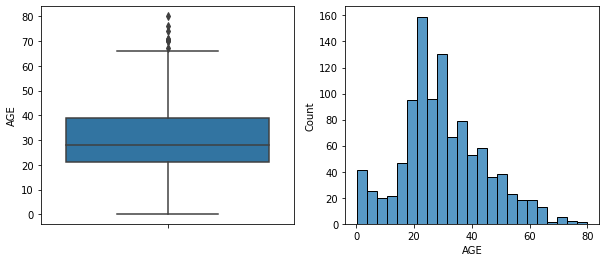


 ########## FARE ##########
          FARE
count 1308.000
mean    33.300
std     51.760
min      0.000
25%      7.900
50%     14.450
75%     31.280
max    512.330


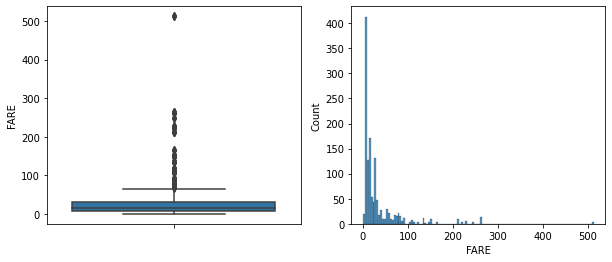

In [8]:
def num_summary(dataframe, numerical_col, plot=False):
    print('\n', '#' * 10, numerical_col.upper(), '#' * 10)
    print(pd.DataFrame({
        numerical_col.upper(): round(dataframe[numerical_col].describe().T, 2)
    }))

    if plot:
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        sns.boxplot(y=dataframe[numerical_col])
        plt.ylabel(numerical_col.upper())
        plt.subplot(1, 2, 2)
        sns.histplot(x=dataframe[numerical_col])
        plt.xlabel(numerical_col.upper())
        plt.show(block=True)

        
for col in num_cols:
    num_summary(df, col, plot=True)

### determining high correlated variables

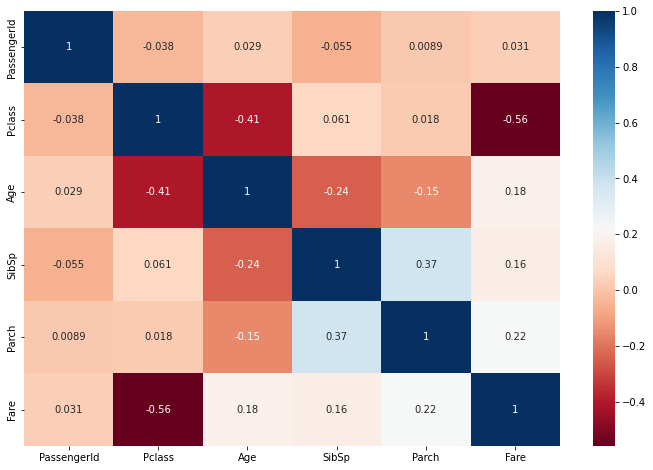

[]

In [9]:
def high_correlated_cols(dataframe, corr_th=0.90, plot=False):
    corr = dataframe.corr()
    cor_matrix = corr.abs()
    upper_triangle_matrix = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(np.bool_))
    drop_list = [col for col in upper_triangle_matrix.columns if any(upper_triangle_matrix[col] > corr_th)]

    if plot:
        plt.figure(figsize=(12, 8))
        sns.heatmap(corr, cmap='RdBu', annot=True, annot_kws={'fontsize': 10})
        plt.show(block=True)

    return drop_list

high_correlated_cols(df, plot=True)   

# Feature engineering

In [10]:
# Cabin Bool
df['new_cabin_bool'] = df['Cabin'].notnull().astype('int')
# Name Count
df['new_name_count'] = df['Name'].str.len()
# Name word count
df['new_name_word_count'] = df['Name'].apply(lambda x: len(str(x).split(' ')))
# Name Dr
df['new_name_dr'] = df['Name'].apply(lambda x: len([x for x in x.split() if x.startswith('Dr.')]))
# Name title
df['new_title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Family size
df['new_family_size'] = df['SibSp'] + df['Parch'] + 1
# Age Pclass
df['new_age_pclass'] = df['Age'] * df['Pclass']
# Is alone?
df.loc[((df['SibSp'] + df['Parch']) > 0), 'new_is_alone'] = 'No'
df.loc[((df['SibSp'] + df['Parch']) == 0), 'new_is_alone'] = 'Yes'
# Age level
df.loc[(df['Age'] < 18), 'new_age_cat'] = 'young'
df.loc[(df['Age'] >= 18) & (df['Age'] < 56), 'new_age_cat'] = 'mature'
df.loc[(df['Age'] >= 56), 'new_age_cat'] = 'senior'
# Sex-Age
df.loc[(df['Sex'] == 'male') & (df['Age'] <= 21), 'new_sex_cat'] = 'youngmale'
df.loc[(df['Sex'] == 'male') & ((df['Age'] > 21) & (df['Age'] <= 50)), 'new_sex_cat'] = 'maturemale'
df.loc[(df['Sex'] == 'male') & (df['Age'] > 50), 'new_sex_cat'] = 'seniormale'                                       
df.loc[(df['Sex'] == 'female') & (df['Age'] <= 21), 'new_sex_cat'] = 'youngfemale'
df.loc[(df['Sex'] == 'female') & ((df['Age'] > 21) & (df['Age'] <= 50)), 'new_sex_cat'] = 'maturefemale'
df.loc[(df['Sex'] == 'female') & (df['Age'] > 50), 'new_sex_cat'] = 'seniorfemale'
# Delete the variables 'Cabin', 'Name', and 'Ticket'
df.drop(['Cabin', 'Name'], axis=1, inplace=True)
# Fill the missing valus of age with its median
df['Age'] = df['Age'].fillna(df.groupby('new_title')['Age'].transform('median'))
# Age Pclass
df['new_age_pclass'] = df['Age'] * df['Pclass']
# Age level
df.loc[(df['Age'] < 18), 'new_age_cat'] = 'young'
df.loc[(df['Age'] >= 18) & (df['Age'] < 56), 'new_age_cat'] = 'mature'
df.loc[(df['Age'] >= 56), 'new_age_cat'] = 'senior'
# Sex-Age
df.loc[(df['Sex'] == 'male') & (df['Age'] <= 21), 'new_sex_cat'] = 'youngmale'
df.loc[(df['Sex'] == 'male') & ((df['Age'] > 21) & (df['Age'] <= 50)), 'new_sex_cat'] = 'maturemale'
df.loc[(df['Sex'] == 'male') & (df['Age'] > 50), 'new_sex_cat'] = 'seniormale'                                       
df.loc[(df['Sex'] == 'female') & (df['Age'] <= 21), 'new_sex_cat'] = 'youngfemale'
df.loc[(df['Sex'] == 'female') & ((df['Age'] > 21) & (df['Age'] <= 50)), 'new_sex_cat'] = 'maturefemale'
df.loc[(df['Sex'] == 'female') & (df['Age'] > 50), 'new_sex_cat'] = 'seniorfemale'
# Fill the missing valus of Embarked with its mode
df = df.apply(lambda x: x.fillna(x.mode()[0]) if (x.dtype == 'O' and len(x.unique()) <= 10) else x, axis=0)

# ticket_prefix
def get_prefix(x):
    # return prefix if prefix is not a number else return 'X'
    pre = x.split(' ')[0]
    if not pre.isnumeric():
        return pre
    return 'X'

df['ticket_prefix'] = df['Ticket'].apply(get_prefix)

tp_count = df['ticket_prefix'].value_counts()
# change prefixes with a frequency of less than 5 to 'X'
df['ticket_prefix'] = df['ticket_prefix'].apply(lambda x: x if  tp_count[x] > 4 else 'X')

# remove Ticket
df.drop('Ticket', axis=1, inplace=True)
df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,new_cabin_bool,new_name_count,new_name_word_count,new_name_dr,new_title,new_family_size,new_age_pclass,new_is_alone,new_age_cat,new_sex_cat,ticket_prefix
0,1,3,male,22.000,1,0,7.250,S,0,23,4,0,Mr,2,66.000,No,mature,maturemale,A/5
1,2,1,female,38.000,1,0,71.283,C,1,51,7,0,Mrs,2,38.000,No,mature,maturefemale,PC
2,3,3,female,26.000,0,0,7.925,S,0,22,3,0,Miss,1,78.000,Yes,mature,maturefemale,STON/O2.
3,4,1,female,35.000,1,0,53.100,S,1,44,7,0,Mrs,2,35.000,No,mature,maturefemale,X
4,5,3,male,35.000,0,0,8.050,S,0,24,4,0,Mr,1,105.000,Yes,mature,maturemale,X
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,male,29.000,0,0,8.050,S,0,18,3,0,Mr,1,87.000,Yes,mature,maturemale,X
1305,1306,1,female,39.000,0,0,108.900,C,1,28,5,0,Dona,1,39.000,Yes,mature,maturefemale,PC
1306,1307,3,male,38.500,0,0,7.250,S,0,28,4,0,Mr,1,115.500,Yes,mature,maturemale,SOTON/O.Q.
1307,1308,3,male,29.000,0,0,8.050,S,0,19,3,0,Mr,1,87.000,Yes,mature,maturemale,X


In [11]:
# Let's show the prequence of the variable 'ticket_prefix'
px.histogram(df, x='ticket_prefix').show()

# Encoding

In [12]:
# Label encoding
def label_encoder(dataframe, binary_col):
    label_encoder = LabelEncoder()
    dataframe[binary_col] = label_encoder.fit_transform(dataframe[binary_col])
    return dataframe

binary_cols = [col for col in df.columns if df[col].dtype not in [int, float] and df[col].nunique() == 2]
for col in binary_cols:
    label_encoder(df, col)
df

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,new_cabin_bool,new_name_count,new_name_word_count,new_name_dr,new_title,new_family_size,new_age_pclass,new_is_alone,new_age_cat,new_sex_cat,ticket_prefix
0,1,3,1,22.000,1,0,7.250,S,0,23,4,0,Mr,2,66.000,No,mature,maturemale,A/5
1,2,1,0,38.000,1,0,71.283,C,1,51,7,0,Mrs,2,38.000,No,mature,maturefemale,PC
2,3,3,0,26.000,0,0,7.925,S,0,22,3,0,Miss,1,78.000,Yes,mature,maturefemale,STON/O2.
3,4,1,0,35.000,1,0,53.100,S,1,44,7,0,Mrs,2,35.000,No,mature,maturefemale,X
4,5,3,1,35.000,0,0,8.050,S,0,24,4,0,Mr,1,105.000,Yes,mature,maturemale,X
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,1,29.000,0,0,8.050,S,0,18,3,0,Mr,1,87.000,Yes,mature,maturemale,X
1305,1306,1,0,39.000,0,0,108.900,C,1,28,5,0,Dona,1,39.000,Yes,mature,maturefemale,PC
1306,1307,3,1,38.500,0,0,7.250,S,0,28,4,0,Mr,1,115.500,Yes,mature,maturemale,SOTON/O.Q.
1307,1308,3,1,29.000,0,0,8.050,S,0,19,3,0,Mr,1,87.000,Yes,mature,maturemale,X


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,new_cabin_bool,new_name_count,new_name_word_count,new_name_dr,new_title,new_family_size,new_age_pclass,new_is_alone,new_age_cat,new_sex_cat,ticket_prefix
0,1,3,1,22.000,1,0,7.250,S,0,23,4,0,Mr,2,66.000,0,mature,maturemale,A/5
1,2,1,0,38.000,1,0,71.283,C,1,51,7,0,Mrs,2,38.000,0,mature,maturefemale,PC
2,3,3,0,26.000,0,0,7.925,S,0,22,3,0,Miss,1,78.000,1,mature,maturefemale,STON/O2.
3,4,1,0,35.000,1,0,53.100,S,1,44,7,0,Mrs,2,35.000,0,mature,maturefemale,X
4,5,3,1,35.000,0,0,8.050,S,0,24,4,0,Mr,1,105.000,1,mature,maturemale,X
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,1,29.000,0,0,8.050,S,0,18,3,0,Mr,1,87.000,1,mature,maturemale,X
1305,1306,1,0,39.000,0,0,108.900,C,1,28,5,0,Dona,1,39.000,1,mature,maturefemale,PC
1306,1307,3,1,38.500,0,0,7.250,S,0,28,4,0,Mr,1,115.500,1,mature,maturemale,SOTON/O.Q.
1307,1308,3,1,29.000,0,0,8.050,S,0,19,3,0,Mr,1,87.000,1,mature,maturemale,X


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,new_cabin_bool,new_name_count,new_name_word_count,new_name_dr,new_title,new_family_size,new_age_pclass,new_is_alone,new_age_cat,new_sex_cat,ticket_prefix
0,1,3,1,22.000,1,0,7.250,S,0,23,4,0,Mr,2,66.000,0,mature,maturemale,A/5
1,2,1,0,38.000,1,0,71.283,C,1,51,7,0,Mrs,2,38.000,0,mature,maturefemale,PC
2,3,3,0,26.000,0,0,7.925,S,0,22,3,0,Miss,1,78.000,1,mature,maturefemale,STON/O2.
3,4,1,0,35.000,1,0,53.100,S,1,44,7,0,Mrs,2,35.000,0,mature,maturefemale,X
4,5,3,1,35.000,0,0,8.050,S,0,24,4,0,Mr,1,105.000,1,mature,maturemale,X
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,3,1,29.000,0,0,8.050,S,0,18,3,0,Mr,1,87.000,1,mature,maturemale,X
1305,1306,1,0,39.000,0,0,108.900,C,1,28,5,0,Dona,1,39.000,1,mature,maturefemale,PC
1306,1307,3,1,38.500,0,0,7.250,S,0,28,4,0,Mr,1,115.500,1,mature,maturemale,SOTON/O.Q.
1307,1308,3,1,29.000,0,0,8.050,S,0,19,3,0,Mr,1,87.000,1,mature,maturemale,X


In [13]:
# OneHot Encoding
def one_hot_encoder(dataframe, categorical_cols, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns = categorical_cols, drop_first=drop_first)
    return dataframe

ohe_cols = [col for col in df.columns if 20 >= df[col].nunique() > 2]
df = one_hot_encoder(df, ohe_cols)
df.head()

,PassengerId,Sex,Age,Fare,new_cabin_bool,new_name_count,new_name_dr,new_age_pclass,new_is_alone,Pclass_2,Pclass_3,SibSp_1,SibSp_2,SibSp_3,SibSp_4,SibSp_5,SibSp_8,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Parch_9,Embarked_Q,Embarked_S,new_name_word_count_4,new_name_word_count_5,new_name_word_count_6,new_name_word_count_7,new_name_word_count_8,new_name_word_count_9,new_name_word_count_14,new_title_Col,new_title_Countess,new_title_Don,new_title_Dona,new_title_Dr,new_title_Jonkheer,new_title_Lady,new_title_Major,new_title_Master,new_title_Miss,new_title_Mlle,new_title_Mme,new_title_Mr,new_title_Mrs,new_title_Ms,new_title_Rev,new_title_Sir,new_family_size_2,new_family_size_3,new_family_size_4,new_family_size_5,new_family_size_6,new_family_size_7,new_family_size_8,new_family_size_11,new_age_cat_senior,new_age_cat_young,new_sex_cat_maturemale,new_sex_cat_seniorfemale,new_sex_cat_seniormale,new_sex_cat_youngfemale,new_sex_cat_youngmale,ticket_prefix_A/5,ticket_prefix_A/5.,ticket_prefix_C,ticket_prefix_C.A.,ticket_prefix_CA,ticket_prefix_CA.,ticket_prefix_F.C.C.,ticket_prefix_PC,ticket_prefix_S.O./P.P.,ticket_prefix_S.O.C.,ticket_prefix_SC/AH,ticket_prefix_SC/PARIS,ticket_prefix_SC/Paris,ticket_prefix_SOTON/O.Q.,ticket_prefix_SOTON/OQ,ticket_prefix_STON/O,ticket_prefix_STON/O2.,ticket_prefix_W./C.,ticket_prefix_X
0,1,1,22.000,7.250,0,23,0,66.000,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,0,38.000,71.283,1,51,0,38.000,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,3,0,26.000,7.925,0,22,0,78.000,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,0,35.000,53.100,1,44,0,35.000,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,5,1,35.000,8.050,0,24,0,105.000,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


# Scaling

In [14]:
cols = [col for col in df.columns if 'PassengerId' not in col]
df[cols] = RobustScaler().fit_transform(df[cols])    
df.head()

,PassengerId,Sex,Age,Fare,new_cabin_bool,new_name_count,new_name_dr,new_age_pclass,new_is_alone,Pclass_2,Pclass_3,SibSp_1,SibSp_2,SibSp_3,SibSp_4,SibSp_5,SibSp_8,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Parch_9,Embarked_Q,Embarked_S,new_name_word_count_4,new_name_word_count_5,new_name_word_count_6,new_name_word_count_7,new_name_word_count_8,new_name_word_count_9,new_name_word_count_14,new_title_Col,new_title_Countess,new_title_Don,new_title_Dona,new_title_Dr,new_title_Jonkheer,new_title_Lady,new_title_Major,new_title_Master,new_title_Miss,new_title_Mlle,new_title_Mme,new_title_Mr,new_title_Mrs,new_title_Ms,new_title_Rev,new_title_Sir,new_family_size_2,new_family_size_3,new_family_size_4,new_family_size_5,new_family_size_6,new_family_size_7,new_family_size_8,new_family_size_11,new_age_cat_senior,new_age_cat_young,new_sex_cat_maturemale,new_sex_cat_seniorfemale,new_sex_cat_seniormale,new_sex_cat_youngfemale,new_sex_cat_youngmale,ticket_prefix_A/5,ticket_prefix_A/5.,ticket_prefix_C,ticket_prefix_C.A.,ticket_prefix_CA,ticket_prefix_CA.,ticket_prefix_F.C.C.,ticket_prefix_PC,ticket_prefix_S.O./P.P.,ticket_prefix_S.O.C.,ticket_prefix_SC/AH,ticket_prefix_SC/PARIS,ticket_prefix_SC/Paris,ticket_prefix_SOTON/O.Q.,ticket_prefix_SOTON/OQ,ticket_prefix_STON/O,ticket_prefix_STON/O2.,ticket_prefix_W./C.,ticket_prefix_X
0,1,0.000,-0.519,-0.308,0.000,-0.200,0.000,0.089,-1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000
1,2,-1.000,0.667,2.431,1.000,2.600,0.000,-0.533,-1.000,0.000,-1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000
2,3,-1.000,-0.222,-0.279,0.000,-0.300,0.000,0.356,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,-1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,-1.000
3,4,-1.000,0.444,1.653,1.000,1.900,0.000,-0.600,-1.000,0.000,-1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,5,0.000,0.444,-0.274,0.000,-0.100,0.000,0.956,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [15]:
df_train = df.iloc[:891, :]
df_train = pd.concat([df_train, df_survived], axis=1)
df_train

,PassengerId,Sex,Age,Fare,new_cabin_bool,new_name_count,new_name_dr,new_age_pclass,new_is_alone,Pclass_2,Pclass_3,SibSp_1,SibSp_2,SibSp_3,SibSp_4,SibSp_5,SibSp_8,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Parch_9,Embarked_Q,Embarked_S,new_name_word_count_4,new_name_word_count_5,new_name_word_count_6,new_name_word_count_7,new_name_word_count_8,new_name_word_count_9,new_name_word_count_14,new_title_Col,new_title_Countess,new_title_Don,new_title_Dona,new_title_Dr,new_title_Jonkheer,new_title_Lady,new_title_Major,new_title_Master,new_title_Miss,new_title_Mlle,new_title_Mme,new_title_Mr,new_title_Mrs,new_title_Ms,new_title_Rev,new_title_Sir,new_family_size_2,new_family_size_3,new_family_size_4,new_family_size_5,new_family_size_6,new_family_size_7,new_family_size_8,new_family_size_11,new_age_cat_senior,new_age_cat_young,new_sex_cat_maturemale,new_sex_cat_seniorfemale,new_sex_cat_seniormale,new_sex_cat_youngfemale,new_sex_cat_youngmale,ticket_prefix_A/5,ticket_prefix_A/5.,ticket_prefix_C,ticket_prefix_C.A.,ticket_prefix_CA,ticket_prefix_CA.,ticket_prefix_F.C.C.,ticket_prefix_PC,ticket_prefix_S.O./P.P.,ticket_prefix_S.O.C.,ticket_prefix_SC/AH,ticket_prefix_SC/PARIS,ticket_prefix_SC/Paris,ticket_prefix_SOTON/O.Q.,ticket_prefix_SOTON/OQ,ticket_prefix_STON/O,ticket_prefix_STON/O2.,ticket_prefix_W./C.,ticket_prefix_X,Survived
0,1,0.000,-0.519,-0.308,0.000,-0.200,0.000,0.089,-1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,0
1,2,-1.000,0.667,2.431,1.000,2.600,0.000,-0.533,-1.000,0.000,-1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,1
2,3,-1.000,-0.222,-0.279,0.000,-0.300,0.000,0.356,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,-1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,-1.000,1
3,4,-1.000,0.444,1.653,1.000,1.900,0.000,-0.600,-1.000,0.000,-1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1
4,5,0.000,0.444,-0.274,0.000,-0.100,0.000,0.956,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [16]:
df_test = df.iloc[891:, :]
df_test

,PassengerId,Sex,Age,Fare,new_cabin_bool,new_name_count,new_name_dr,new_age_pclass,new_is_alone,Pclass_2,Pclass_3,SibSp_1,SibSp_2,SibSp_3,SibSp_4,SibSp_5,SibSp_8,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Parch_9,Embarked_Q,Embarked_S,new_name_word_count_4,new_name_word_count_5,new_name_word_count_6,new_name_word_count_7,new_name_word_count_8,new_name_word_count_9,new_name_word_count_14,new_title_Col,new_title_Countess,new_title_Don,new_title_Dona,new_title_Dr,new_title_Jonkheer,new_title_Lady,new_title_Major,new_title_Master,new_title_Miss,new_title_Mlle,new_title_Mme,new_title_Mr,new_title_Mrs,new_title_Ms,new_title_Rev,new_title_Sir,new_family_size_2,new_family_size_3,new_family_size_4,new_family_size_5,new_family_size_6,new_family_size_7,new_family_size_8,new_family_size_11,new_age_cat_senior,new_age_cat_young,new_sex_cat_maturemale,new_sex_cat_seniorfemale,new_sex_cat_seniormale,new_sex_cat_youngfemale,new_sex_cat_youngmale,ticket_prefix_A/5,ticket_prefix_A/5.,ticket_prefix_C,ticket_prefix_C.A.,ticket_prefix_CA,ticket_prefix_CA.,ticket_prefix_F.C.C.,ticket_prefix_PC,ticket_prefix_S.O./P.P.,ticket_prefix_S.O.C.,ticket_prefix_SC/AH,ticket_prefix_SC/PARIS,ticket_prefix_SC/Paris,ticket_prefix_SOTON/O.Q.,ticket_prefix_SOTON/OQ,ticket_prefix_STON/O,ticket_prefix_STON/O2.,ticket_prefix_W./C.,ticket_prefix_X
891,892,0.000,0.407,-0.283,0.000,-0.900,0.000,0.922,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,-1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
892,893,-1.000,1.333,-0.319,0.000,0.700,0.000,1.756,-1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
893,894,0.000,2.444,-0.204,0.000,0.000,0.000,1.378,0.000,1.000,-1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,-1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
894,895,0.000,-0.148,-0.248,0.000,-0.900,0.000,0.422,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
895,896,-1.000,-0.519,-0.093,0.000,1.900,0.000,0.089,-1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

# Modeling

## Selecting the independent and dependent variables

In [17]:
y = df_train['Survived']
X = df_train.drop(['PassengerId', 'Survived'], axis=1)

# Lazy Regressor

In [18]:
X_train, y_train, X_test, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, y_train, X_test, y_test)
print(models)

100%|██████████| 29/29 [00:05<00:00,  4.88it/s]

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  Time Taken
Model                                                                                    
AdaBoostClassifier                0.804              0.788    0.788     0.802       0.130
LogisticRegression                0.777              0.756    0.756     0.773       0.070
KNeighborsClassifier              0.777              0.752    0.752     0.771       0.042
CalibratedClassifierCV            0.771              0.745    0.745     0.764       0.899
RidgeClassifierCV                 0.771              0.745    0.745     0.764       0.079
RidgeClassifier                   0.771              0.745    0.745     0.764       0.046
LinearDiscriminantAnalysis        0.771              0.745    0.745     0.764       0.096
NearestCentroid                   0.754              0.741    0.741     0.753       0.028
SVC                               0.771              0.741    0.741     0.762       0.104
LinearSVC 

# AdaBoost Classifier

In [19]:
ada_boost = AdaBoostClassifier().fit(X, y)

# estimating the errors before hyperparameter optimization
adaboost_cv_results = cross_validate(ada_boost, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'])
print('Accuracy:', adaboost_cv_results['test_accuracy'].mean())
print('F1 Score:', adaboost_cv_results['test_f1'].mean())
print('Roc Auc Score:', adaboost_cv_results['test_roc_auc'].mean())

# hypreparameter optimization
print('--'*50)
print(ada_boost.get_params())
print('--'*50)
adaboost_params = {'learning_rate': [0.01, 0.05, 0.1],
              'n_estimators': [50, 100, 300, 500, 1000]}

# Using GridSearchCv method
adaboost_best_grid = GridSearchCV(ada_boost, adaboost_params, cv=10, n_jobs=-1, verbose=True).fit(X, y)

adaboost_best_grid.best_params_
print('--'*50)

# final model
adaboost_final = ada_boost.set_params(**adaboost_best_grid.best_params_, random_state=1).fit(X, y)

# estimating the errors after hyperparameter optimization
adaboost_cv_results = cross_validate(adaboost_final, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'])
print('Accuracy:', adaboost_cv_results['test_accuracy'].mean())
print('F1 Score:', adaboost_cv_results['test_f1'].mean())
print('Roc Auc Score:', adaboost_cv_results['test_roc_auc'].mean())

# prediction
print('--'*50)
adaboost_final.predict(X)

Accuracy: 0.8092134831460672
F1 Score: 0.7439744230986738
Roc Auc Score: 0.8563842345018816
----------------------------------------------------------------------------------------------------
{'algorithm': 'SAMME.R', 'base_estimator': None, 'learning_rate': 1.0, 'n_estimators': 50, 'random_state': None}
----------------------------------------------------------------------------------------------------
Fitting 10 folds for each of 15 candidates, totalling 150 fits


{'learning_rate': 0.05, 'n_estimators': 500}

----------------------------------------------------------------------------------------------------
Accuracy: 0.8226841448189763
F1 Score: 0.7633757820062799
Roc Auc Score: 0.8708246328834564
----------------------------------------------------------------------------------------------------


array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,

[[491  58]
 [ 78 264]]
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       549
           1       0.82      0.77      0.80       342

    accuracy                           0.85       891
   macro avg       0.84      0.83      0.84       891
weighted avg       0.85      0.85      0.85       891

----------------------------------------------------------------------------------------------------


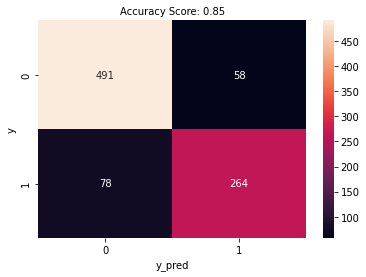

----------------------------------------------------------------------------------------------------


Text(0.5, 1.0, 'ROC Curve')

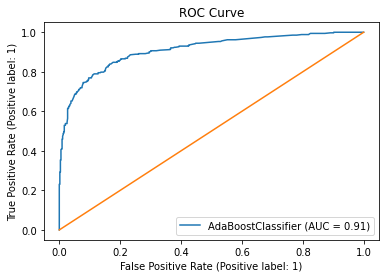

In [20]:
# confusion matrix
y_pred = adaboost_final.predict(X)
print(confusion_matrix(y, y_pred))
print('--'*50)

# classification report
print(classification_report(y, y_pred))
print('--'*50)

# figure of classification report
def plot_confusion_matrix(y, y_pred):
    acc = round(accuracy_score(y, y_pred), 2)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt=".0f")
    plt.xlabel('y_pred')
    plt.ylabel('y')
    plt.title('Accuracy Score: {0}'.format(acc), size=10)
    plt.show()

plot_confusion_matrix(y, y_pred)
print('--'*50)

# getting roc curve
plot_roc_curve(adaboost_final, X, y)
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1])
plt.show()

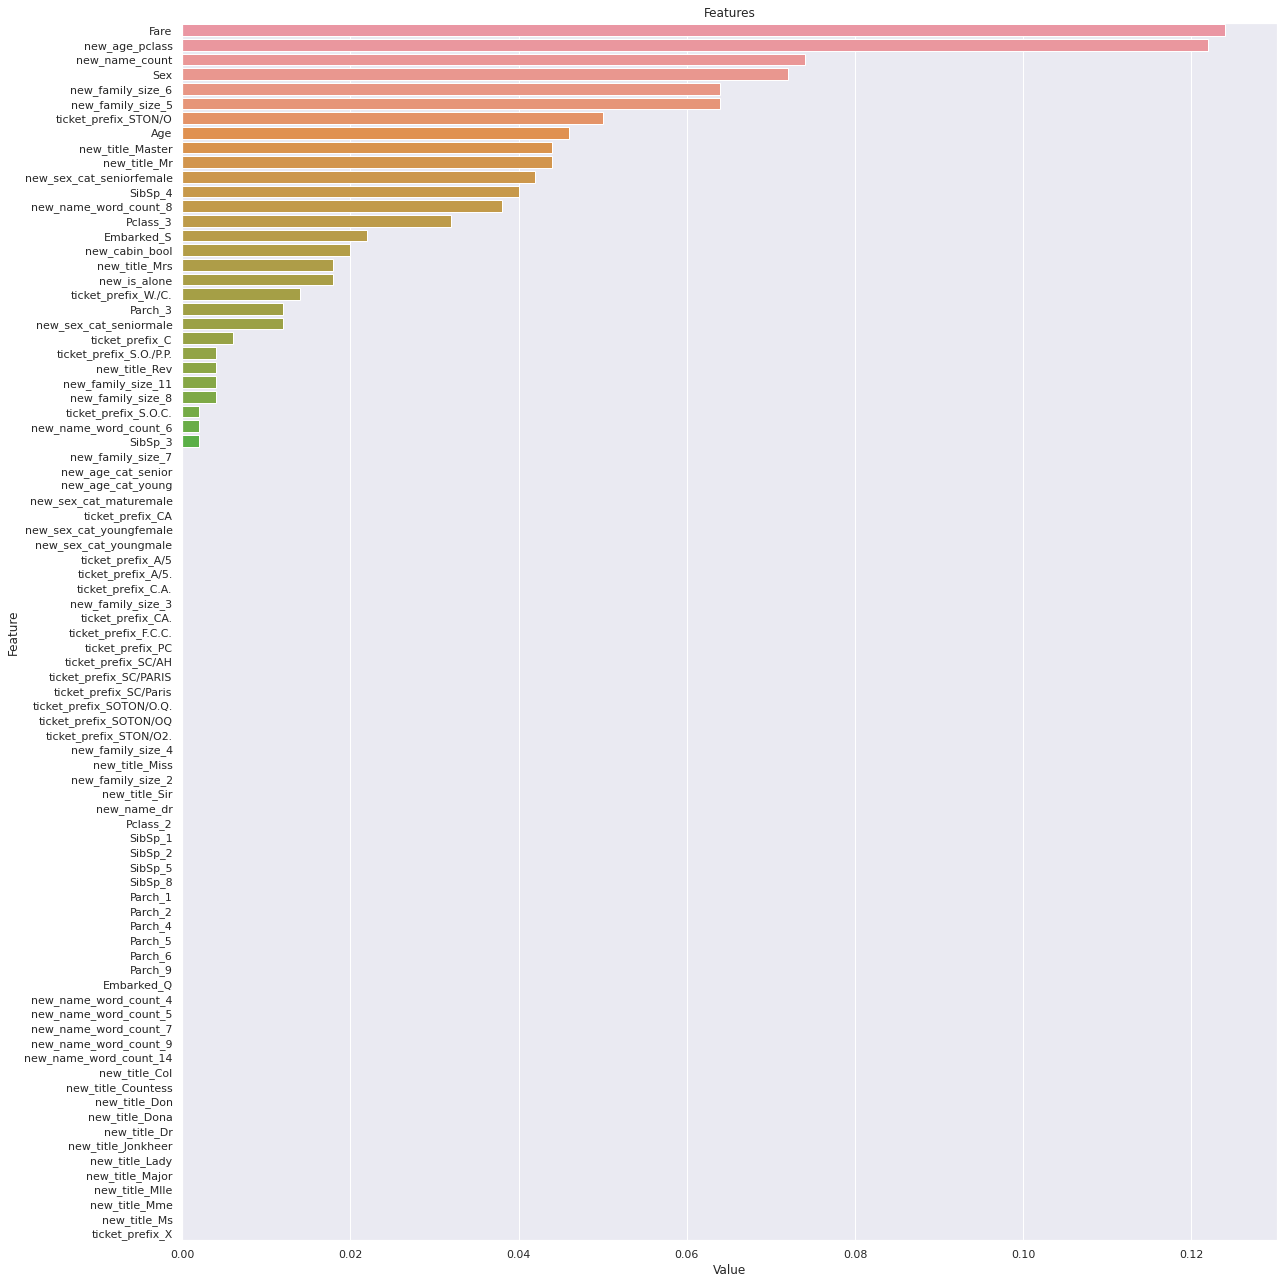

In [21]:
def plot_importance(model, features, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(18, 18))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig('importances.png')

plot_importance(adaboost_final, X)

# LightGBM Model

In [22]:
# model establishing
lgbm_model = LGBMClassifier(random_state=1).fit(X, y)

# estimating the errors before hyperparameter optimization
lgbm_cv_results = cross_validate(lgbm_model, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'])
print('Accuracy:', lgbm_cv_results['test_accuracy'].mean())
print('F1 Score:', lgbm_cv_results['test_f1'].mean())
print('Roc Auc Score:', lgbm_cv_results['test_roc_auc'].mean())

# hypreparameter optimization
print('--'*50)
print(lgbm_model.get_params())
print('--'*50)
lgbm_params = {'learning_rate': [0.01, 0.05, 0.1],
              'n_estimators': [100, 300, 500, 1000]}

# Using GridSearchCv method
lgbm_best_grid = GridSearchCV(lgbm_model, lgbm_params, cv=10, n_jobs=-1, verbose=True).fit(X, y)

lgbm_best_grid.best_params_
print('--'*50)

# final model
lgbm_final = lgbm_model.set_params(**lgbm_best_grid.best_params_, random_state=1).fit(X, y)

# estimating the errors after hyperparameter optimization
lgbm_cv_results = cross_validate(lgbm_final, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'])
print('Accuracy:', lgbm_cv_results['test_accuracy'].mean())
print('F1 Score:', lgbm_cv_results['test_f1'].mean())
print('Roc Auc Score:', lgbm_cv_results['test_roc_auc'].mean())

# prediction
print('--'*50)
lgbm_final.predict(X)

Accuracy: 0.8204494382022472
F1 Score: 0.7492250825909976
Roc Auc Score: 0.8684632883456412
----------------------------------------------------------------------------------------------------
{'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0, 'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0, 'n_estimators': 100, 'n_jobs': -1, 'num_leaves': 31, 'objective': None, 'random_state': 1, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'silent': 'warn', 'subsample': 1.0, 'subsample_for_bin': 200000, 'subsample_freq': 0}
----------------------------------------------------------------------------------------------------
Fitting 10 folds for each of 12 candidates, totalling 120 fits


{'learning_rate': 0.05, 'n_estimators': 100}

----------------------------------------------------------------------------------------------------
Accuracy: 0.8305368289637952
F1 Score: 0.7622384915397236
Roc Auc Score: 0.8724585349291232
----------------------------------------------------------------------------------------------------


array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,

[[531  18]
 [ 35 307]]
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       549
           1       0.94      0.90      0.92       342

    accuracy                           0.94       891
   macro avg       0.94      0.93      0.94       891
weighted avg       0.94      0.94      0.94       891

----------------------------------------------------------------------------------------------------


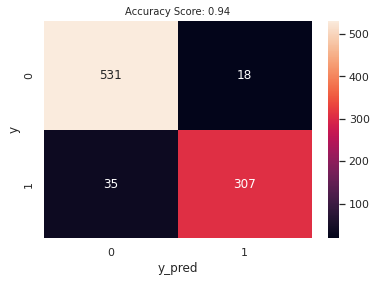

----------------------------------------------------------------------------------------------------


Text(0.5, 1.0, 'ROC Curve')

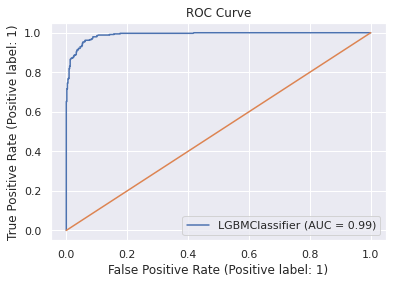

In [23]:
# confusion matrix
y_pred = lgbm_final.predict(X)
print(confusion_matrix(y, y_pred))
print('--'*50)

# classification report
print(classification_report(y, y_pred))
print('--'*50)

# figure of classification report
def plot_confusion_matrix(y, y_pred):
    acc = round(accuracy_score(y, y_pred), 2)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt=".0f")
    plt.xlabel('y_pred')
    plt.ylabel('y')
    plt.title('Accuracy Score: {0}'.format(acc), size=10)
    plt.show()

plot_confusion_matrix(y, y_pred)
print('--'*50)

# getting roc curve
plot_roc_curve(lgbm_final, X, y)
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1])
plt.show()

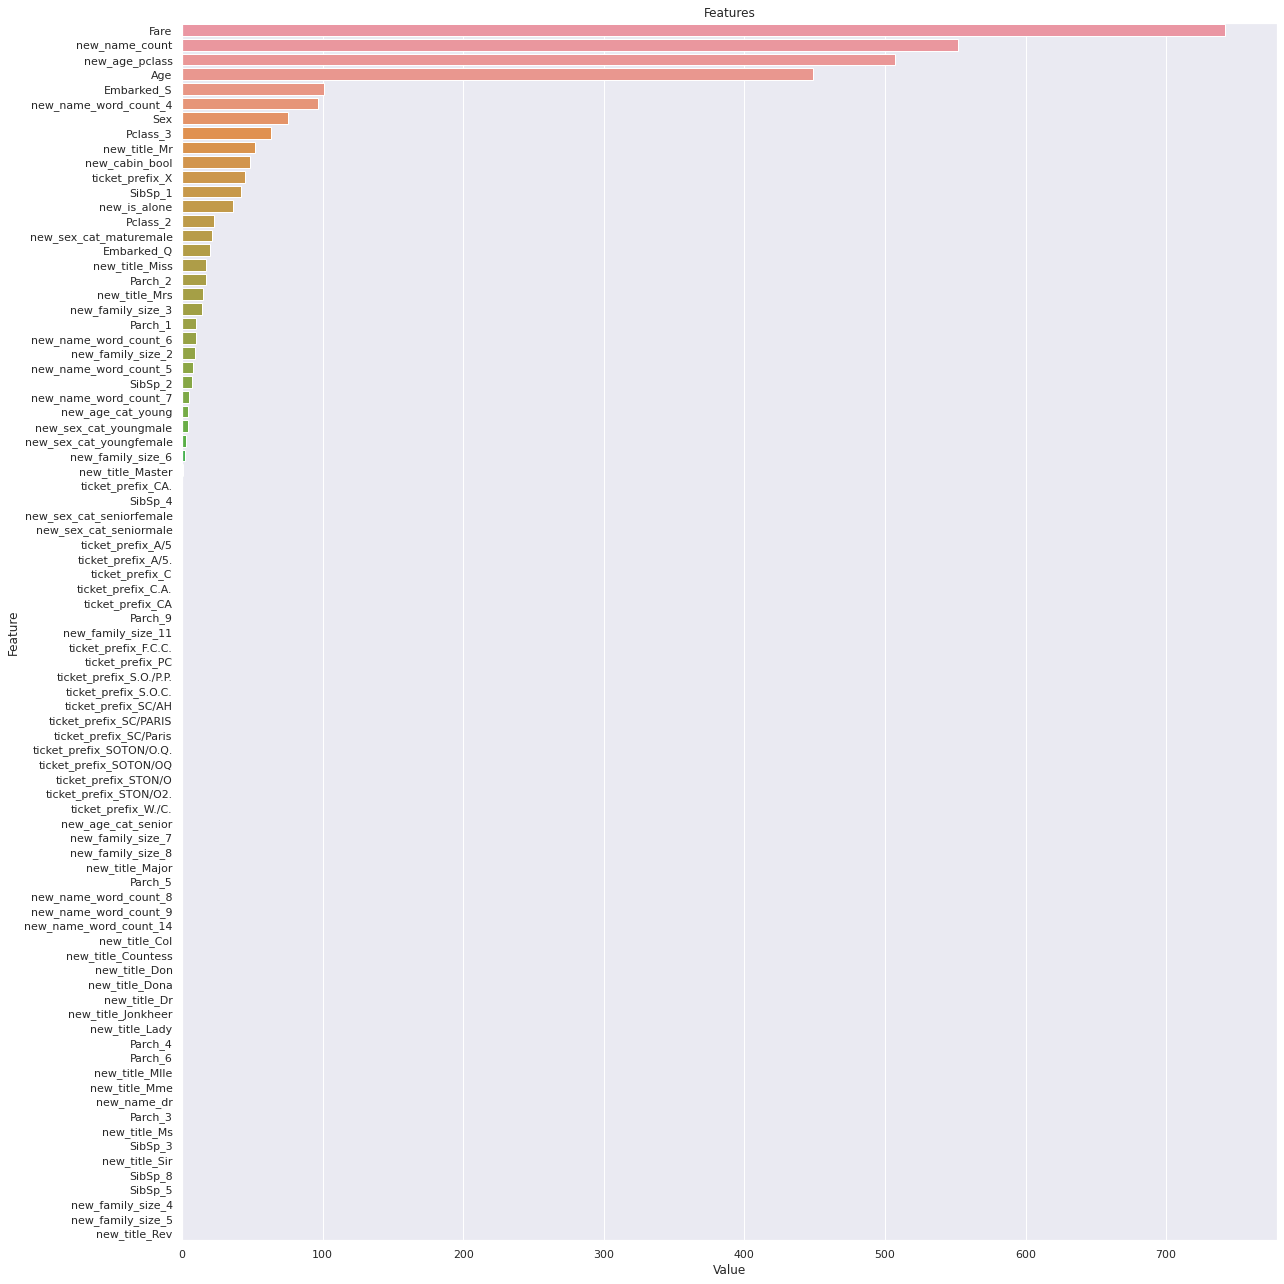

In [24]:
def plot_importance(model, features, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(18, 18))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig('importances.png')

plot_importance(lgbm_final, X)

# Random Forest Classififer

In [25]:
# model establishing
rf_model = RandomForestClassifier().fit(X, y)

# estimating the errors before hyperparameter optimization
rf_cv_results = cross_validate(rf_model, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'])
print('Accuracy:', rf_cv_results['test_accuracy'].mean())
print('F1 Score:', rf_cv_results['test_f1'].mean())
print('Roc Auc Score:', rf_cv_results['test_roc_auc'].mean())

# hypreparameter optimization
print('--'*50)
print(rf_model.get_params())
print('--'*50)

rf_params = {'max_depth': [5, 8, None],
             'max_features': [3, 5, 7, 'auto'],
            'min_samples_split': [2, 5, 8, 15, 20],
            'n_estimators': [100, 200, 500]}

# Using GridSearchCv method
rf_best_grid = GridSearchCV(rf_model, rf_params, cv=10, n_jobs=-1, verbose=True).fit(X, y)
rf_best_grid.best_params_
print('--'*50)

# final model
rf_final = rf_model.set_params(**rf_best_grid.best_params_, random_state=1).fit(X, y)

# estimating the errors after hyperparameter optimization
rf_cv_results = cross_validate(rf_final, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'])
print('Accuracy:', rf_cv_results['test_accuracy'].mean())
print('F1 Score:', rf_cv_results['test_f1'].mean())
print('Roc Auc Score:', rf_cv_results['test_roc_auc'].mean())

# prediction
print('--'*50)
rf_final.predict(X)

Accuracy: 0.8170661672908863
F1 Score: 0.7467515844313157
Roc Auc Score: 0.8680996519820049
----------------------------------------------------------------------------------------------------
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'auto', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
----------------------------------------------------------------------------------------------------
Fitting 10 folds for each of 180 candidates, totalling 1800 fits


{'max_depth': 8,
 'max_features': 'auto',
 'min_samples_split': 2,
 'n_estimators': 500}

----------------------------------------------------------------------------------------------------
Accuracy: 0.8350312109862671
F1 Score: 0.7678540503743783
Roc Auc Score: 0.8731599751011515
----------------------------------------------------------------------------------------------------


array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,

[[524  25]
 [ 63 279]]
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.95      0.92       549
           1       0.92      0.82      0.86       342

    accuracy                           0.90       891
   macro avg       0.91      0.89      0.89       891
weighted avg       0.90      0.90      0.90       891

----------------------------------------------------------------------------------------------------


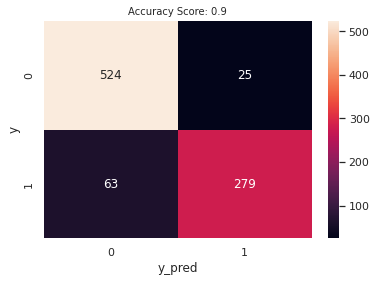

----------------------------------------------------------------------------------------------------


Text(0.5, 1.0, 'ROC Curve')

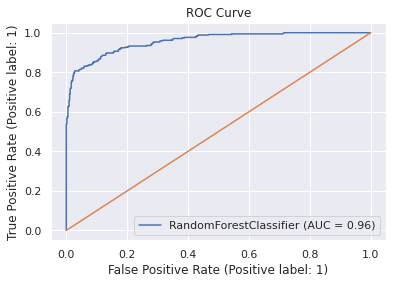

In [26]:
# confusion matrix
y_pred = rf_final.predict(X)
print(confusion_matrix(y, y_pred))
print('--'*50)

# classification report
print(classification_report(y, y_pred))
print('--'*50)

# figure of classification report
def plot_confusion_matrix(y, y_pred):
    acc = round(accuracy_score(y, y_pred), 2)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt=".0f")
    plt.xlabel('y_pred')
    plt.ylabel('y')
    plt.title('Accuracy Score: {0}'.format(acc), size=10)
    plt.show()

plot_confusion_matrix(y, y_pred)
print('--'*50)

# getting roc curve
plot_roc_curve(rf_final, X, y)
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1])
plt.show()

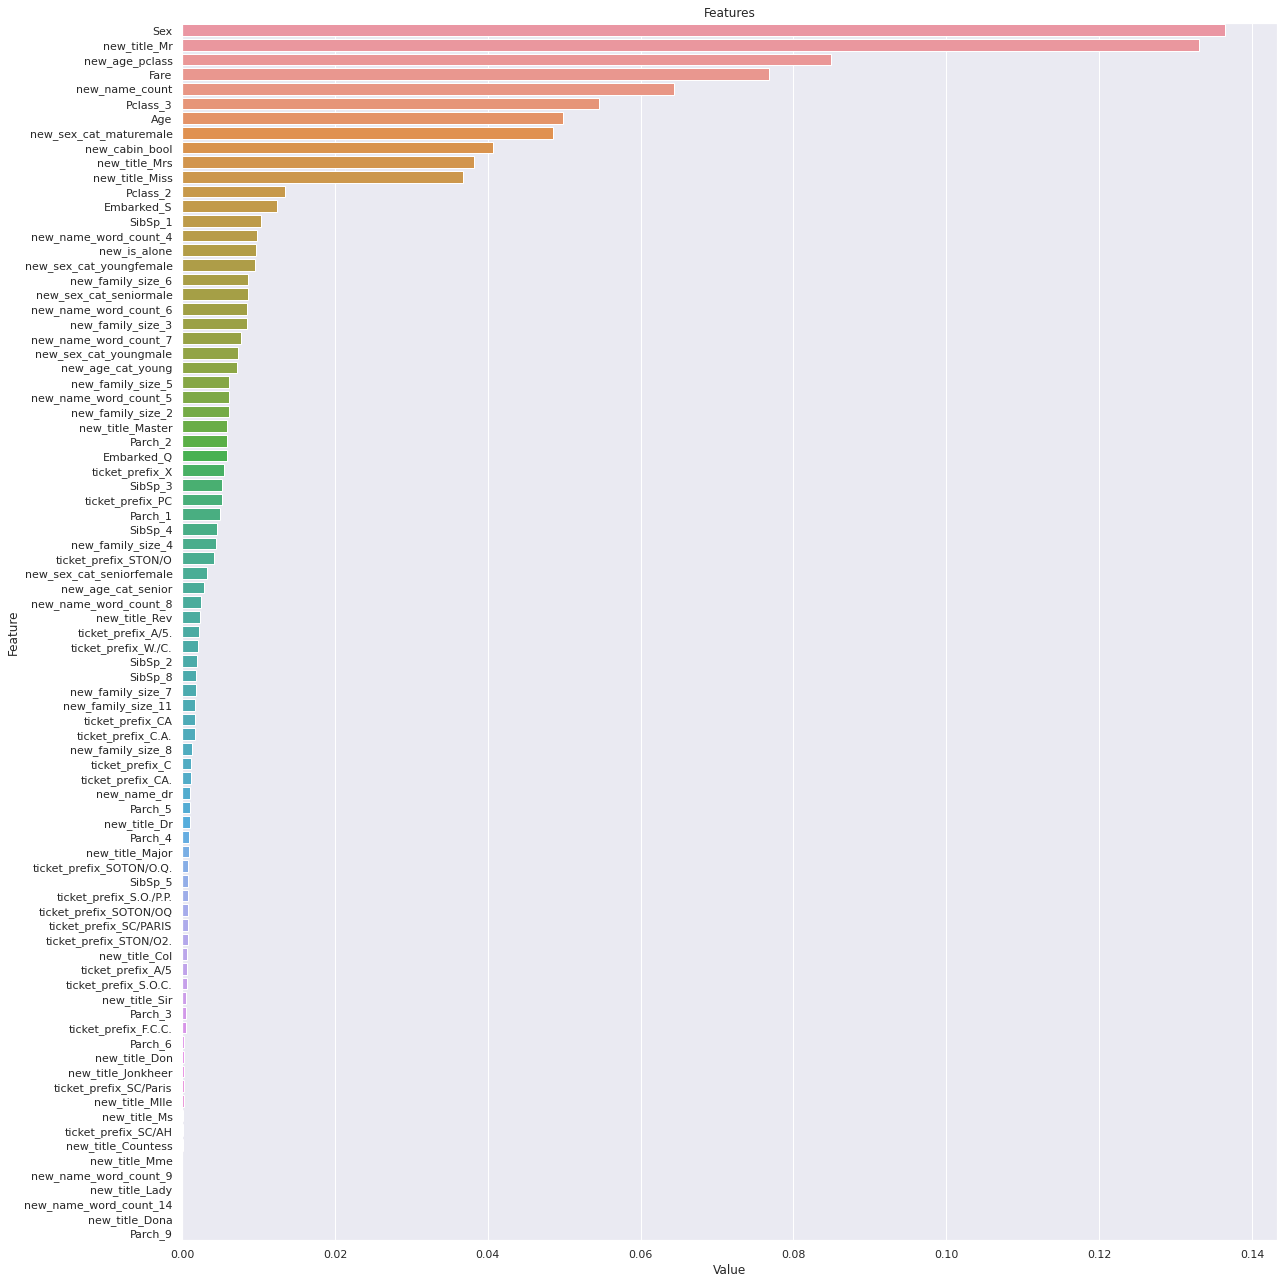

In [27]:
def plot_importance(model, features, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(18, 18))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig('importances.png')

plot_importance(rf_final, X)

# Decision Tree Classifier

In [28]:
# model establishing
cart_model = DecisionTreeClassifier(random_state=1)

# estimating the errors before hyperparameter optimization
cart_cv_results = cross_validate(cart_model, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'])
print('Accuracy:', cart_cv_results['test_accuracy'].mean())
print('F1 Score:', cart_cv_results['test_f1'].mean())
print('Roc Auc Score:', cart_cv_results['test_roc_auc'].mean())

# hypreparameter optimization
print('--'*50)
print(cart_model.get_params())
print('--'*50)
cart_params = {'max_depth': range(1, 11),
               'min_samples_split': range(2, 20)}

# Using GridSearchCv method
cart_best_grid = GridSearchCV(cart_model, cart_params, cv=10, n_jobs=-1, verbose=True).fit(X, y)

# final model
cart_final = cart_model.set_params(**cart_best_grid.best_params_, random_state=1).fit(X, y)

# estimating the errors after hyperparameter optimization
cart_cv_results = cross_validate(cart_final, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'])
print('Accuracy:', cart_cv_results['test_accuracy'].mean())
print('F1 Score:', cart_cv_results['test_f1'].mean())
print('Roc Auc Score:', cart_cv_results['test_roc_auc'].mean())

# prediction
print('--'*50)
cart_final.predict(X)

Accuracy: 0.7543196004993756
F1 Score: 0.6885799945782691
Roc Auc Score: 0.7462039724980902
----------------------------------------------------------------------------------------------------
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'random_state': 1, 'splitter': 'best'}
----------------------------------------------------------------------------------------------------
Fitting 10 folds for each of 180 candidates, totalling 1800 fits
Accuracy: 0.8237827715355805
F1 Score: 0.7598617905702436
Roc Auc Score: 0.8619822312763489
----------------------------------------------------------------------------------------------------


array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,

[[494  55]
 [ 71 271]]
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.87      0.90      0.89       549
           1       0.83      0.79      0.81       342

    accuracy                           0.86       891
   macro avg       0.85      0.85      0.85       891
weighted avg       0.86      0.86      0.86       891

----------------------------------------------------------------------------------------------------


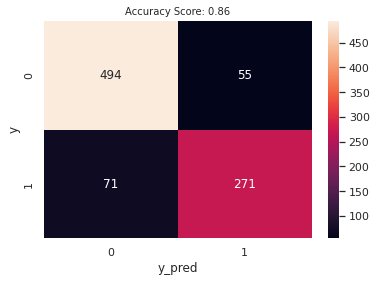

----------------------------------------------------------------------------------------------------


Text(0.5, 1.0, 'ROC Curve')

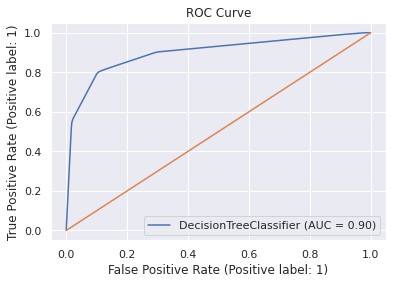

In [29]:
# confusion matrix
y_pred = cart_final.predict(X)
print(confusion_matrix(y, y_pred))
print('--'*50)

# classification report
print(classification_report(y, y_pred))
print('--'*50)

# figure of classification report
def plot_confusion_matrix(y, y_pred):
    acc = round(accuracy_score(y, y_pred), 2)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt=".0f")
    plt.xlabel('y_pred')
    plt.ylabel('y')
    plt.title('Accuracy Score: {0}'.format(acc), size=10)
    plt.show()

plot_confusion_matrix(y, y_pred)
print('--'*50)

# getting roc curve
plot_roc_curve(cart_final, X, y)
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1])
plt.show()

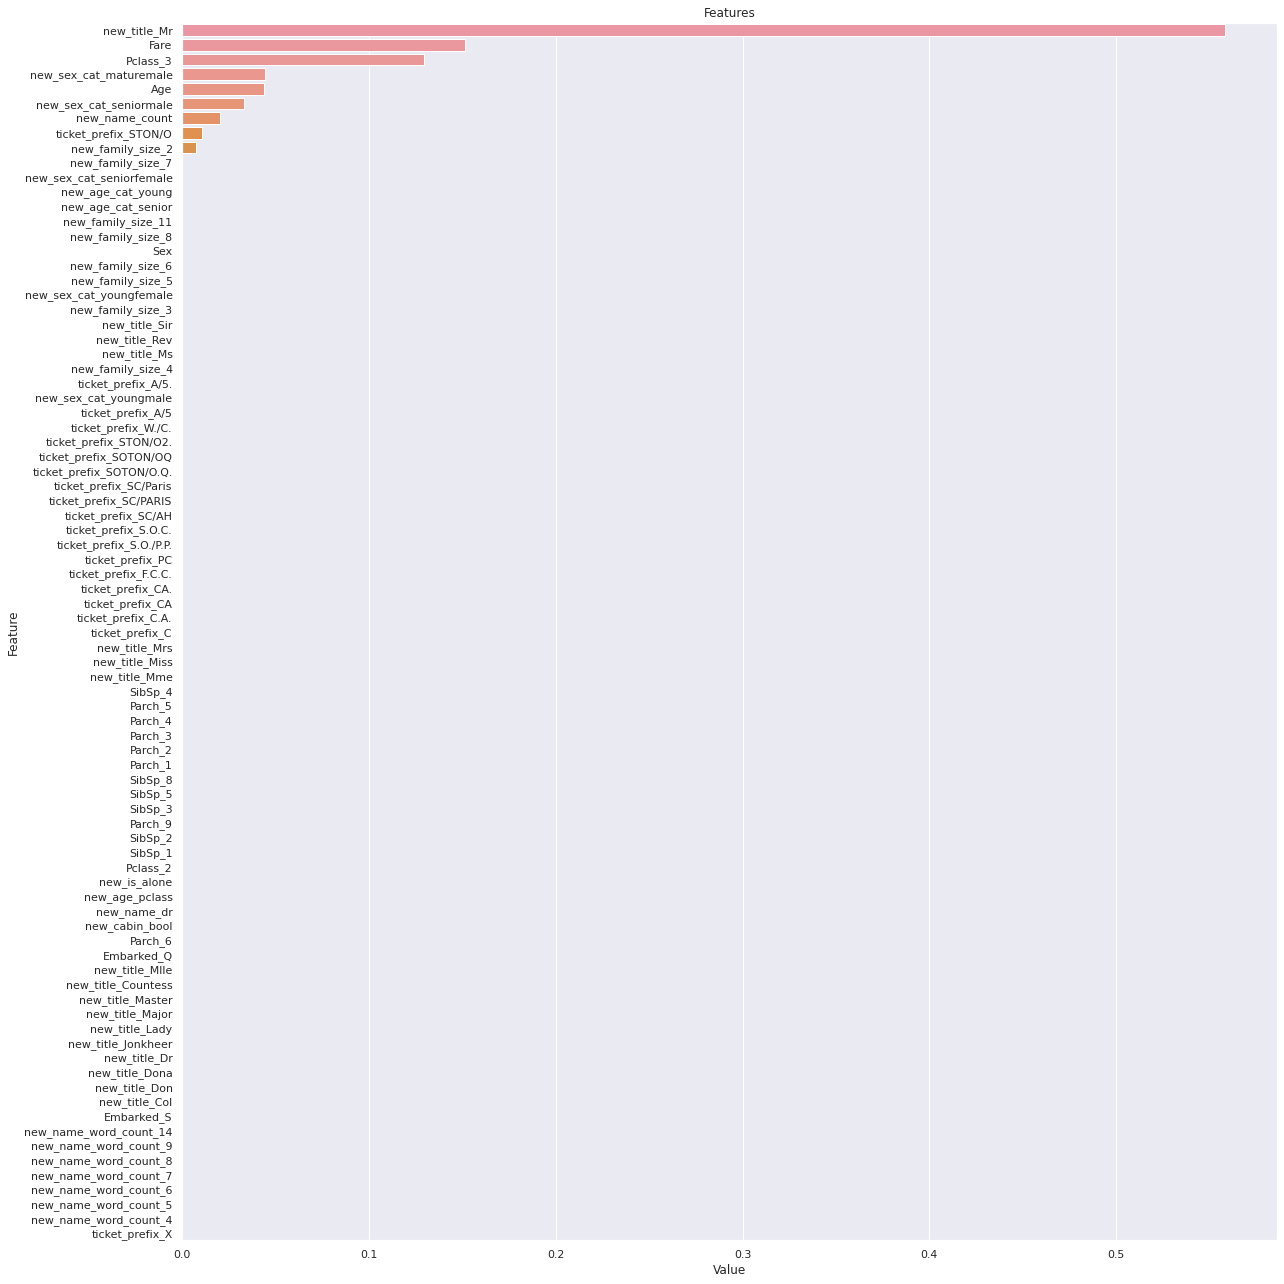

In [30]:
def plot_importance(model, features, num=len(X), save=False):
    feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features.columns})
    plt.figure(figsize=(18, 18))
    sns.set(font_scale=1)
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False)[0:num])
    plt.title('Features')
    plt.tight_layout()
    plt.show()
    if save:
        plt.savefig('importances.png')

plot_importance(cart_final, X)

# Logistic Regression

Accuracy: 0.8305368289637952
F1 Score: 0.7677494009934117
Roc Auc Score: 0.8723890445066915
----------------------------------------------------------------------------------------------------


array([-1.92677921])

array([[-1.38300361, -0.05918816,  0.11742567,  0.79741706,  0.18679981,
        -0.27565458, -0.51778667,  1.00660601, -0.03183655, -0.77543029,
        -0.00345112,  0.30572982, -0.49725543, -0.89284442, -0.47177474,
        -0.5712376 , -0.14968989, -0.37697641,  0.61489805, -0.4297039 ,
        -0.22220998, -0.12605434,  0.        , -0.01712275, -0.46349603,
        -0.12980091,  0.00759718,  0.30436473,  0.37513134, -0.9820488 ,
         0.09972011,  0.01498351,  0.16582786,  0.08715733, -0.35011377,
         0.        , -0.27565458, -0.35266972,  0.10941854, -0.09504379,
         1.5661393 ,  0.15623275,  0.08971981,  0.06069759, -0.95964889,
         0.49742079,  0.19448972, -0.80351984,  0.2303694 ,  0.57792024,
         0.79647744,  0.74457429, -1.00867799, -1.18524332,  0.23741001,
        -0.59782909, -0.5712376 , -0.24914105,  0.37494597, -0.21015074,
         0.73709461, -0.68468432, -0.37597119, -0.48797237,  0.24288892,
        -0.33779021,  0.7309784 ,  0.3026111 , -0.5

----------------------------------------------------------------------------------------------------
[[493  56]
 [ 79 263]]
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       549
           1       0.82      0.77      0.80       342

    accuracy                           0.85       891
   macro avg       0.84      0.83      0.84       891
weighted avg       0.85      0.85      0.85       891

----------------------------------------------------------------------------------------------------


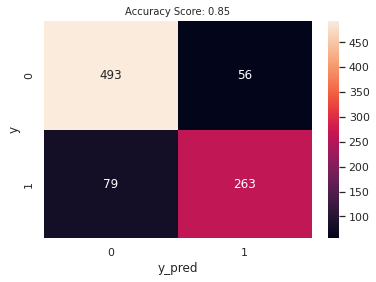

----------------------------------------------------------------------------------------------------


Text(0.5, 1.0, 'ROC Curve')

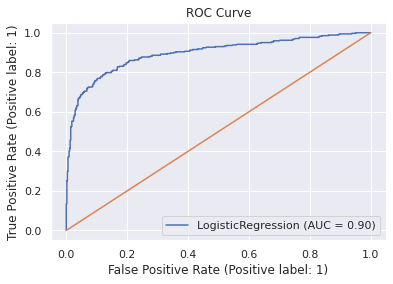

In [31]:
# model establishing
log_model = LogisticRegression().fit(X, y)

# estimating the errors before hyperparameter optimization
log_cv_results = cross_validate(log_model, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'])
print('Accuracy:', log_cv_results['test_accuracy'].mean())
print('F1 Score:', log_cv_results['test_f1'].mean())
print('Roc Auc Score:', log_cv_results['test_roc_auc'].mean())
print('--'*50)

# bias and weights
log_model.intercept_
log_model.coef_
print('--'*50)

# confusion matrix
y_pred = log_model.predict(X)
print(confusion_matrix(y, y_pred))
print('--'*50)

# classification report
print(classification_report(y, y_pred))
print('--'*50)

# figure of classification report
def plot_confusion_matrix(y, y_pred):
    acc = round(accuracy_score(y, y_pred), 2)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt=".0f")
    plt.xlabel('y_pred')
    plt.ylabel('y')
    plt.title('Accuracy Score: {0}'.format(acc), size=10)
    plt.show()

plot_confusion_matrix(y, y_pred)
print('--'*50)

# getting roc curve
plot_roc_curve(log_model, X, y)
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1])
plt.show()

# KNN Model

In [32]:
knn_model = KNeighborsClassifier().fit(X, y)
print(knn_model.get_params())

{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}


In [33]:
# model establishing
knn_model = KNeighborsClassifier().fit(X, y)

# estimating the errors before hyperparameter optimization
knn_cv_results = cross_validate(knn_model, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'])
print('Accuracy:', knn_cv_results['test_accuracy'].mean())
print('F1 Score:', knn_cv_results['test_f1'].mean())
print('Roc Auc Score:', knn_cv_results['test_roc_auc'].mean())
print('--'*50)

# hypreparameter optimization
print('--'*50)
print(knn_model.get_params())
print('--'*50)
knn_params = {'n_neighbors': range(2, 50)}

# Using GridSearchCv method
knn_best_grid = GridSearchCV(knn_model, knn_params, cv=10, n_jobs=-1, verbose=True).fit(X, y)
knn_best_grid.best_params_
print('--'*50)

# final model
knn_final = knn_model.set_params(**knn_best_grid.best_params_).fit(X, y)

# estimating the errors after hyperparameter optimization
knn_cv_results = cross_validate(knn_final, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc'])
print('Accuracy:', knn_cv_results['test_accuracy'].mean())
print('F1 Score:', knn_cv_results['test_f1'].mean())
print('Roc Auc Score:', knn_cv_results['test_roc_auc'].mean())

# prediction
print('--'*50)
knn_final.predict(X)

Accuracy: 0.8193757802746567
F1 Score: 0.7524112130011189
Roc Auc Score: 0.851671363494893
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
----------------------------------------------------------------------------------------------------
Fitting 10 folds for each of 48 candidates, totalling 480 fits


{'n_neighbors': 10}

----------------------------------------------------------------------------------------------------
Accuracy: 0.8204868913857677
F1 Score: 0.7391012119824036
Roc Auc Score: 0.868419234360411
----------------------------------------------------------------------------------------------------


array([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,

[[512  37]
 [101 241]]
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       549
           1       0.87      0.70      0.78       342

    accuracy                           0.85       891
   macro avg       0.85      0.82      0.83       891
weighted avg       0.85      0.85      0.84       891

----------------------------------------------------------------------------------------------------


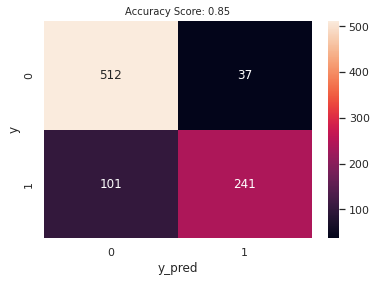

----------------------------------------------------------------------------------------------------


Text(0.5, 1.0, 'ROC Curve')

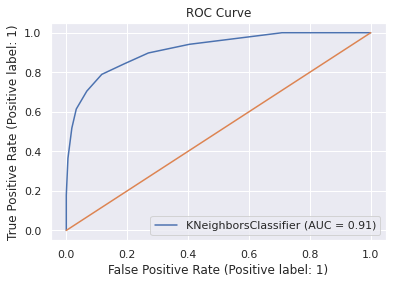

In [34]:
# confusion matrix
y_pred = knn_final.predict(X)
print(confusion_matrix(y, y_pred))
print('--'*50)

# classification report
print(classification_report(y, y_pred))
print('--'*50)

# figure of classification report
def plot_confusion_matrix(y, y_pred):
    acc = round(accuracy_score(y, y_pred), 2)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt=".0f")
    plt.xlabel('y_pred')
    plt.ylabel('y')
    plt.title('Accuracy Score: {0}'.format(acc), size=10)
    plt.show()

plot_confusion_matrix(y, y_pred)
print('--'*50)

# getting roc curve
plot_roc_curve(knn_final, X, y)
plt.title('ROC Curve')
plt.plot([0, 1], [0, 1])
plt.show()

# Let's operate the models on test set

In [35]:
X_test = df_test.drop(['PassengerId'], axis = 1)
X_test

,Sex,Age,Fare,new_cabin_bool,new_name_count,new_name_dr,new_age_pclass,new_is_alone,Pclass_2,Pclass_3,SibSp_1,SibSp_2,SibSp_3,SibSp_4,SibSp_5,SibSp_8,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Parch_9,Embarked_Q,Embarked_S,new_name_word_count_4,new_name_word_count_5,new_name_word_count_6,new_name_word_count_7,new_name_word_count_8,new_name_word_count_9,new_name_word_count_14,new_title_Col,new_title_Countess,new_title_Don,new_title_Dona,new_title_Dr,new_title_Jonkheer,new_title_Lady,new_title_Major,new_title_Master,new_title_Miss,new_title_Mlle,new_title_Mme,new_title_Mr,new_title_Mrs,new_title_Ms,new_title_Rev,new_title_Sir,new_family_size_2,new_family_size_3,new_family_size_4,new_family_size_5,new_family_size_6,new_family_size_7,new_family_size_8,new_family_size_11,new_age_cat_senior,new_age_cat_young,new_sex_cat_maturemale,new_sex_cat_seniorfemale,new_sex_cat_seniormale,new_sex_cat_youngfemale,new_sex_cat_youngmale,ticket_prefix_A/5,ticket_prefix_A/5.,ticket_prefix_C,ticket_prefix_C.A.,ticket_prefix_CA,ticket_prefix_CA.,ticket_prefix_F.C.C.,ticket_prefix_PC,ticket_prefix_S.O./P.P.,ticket_prefix_S.O.C.,ticket_prefix_SC/AH,ticket_prefix_SC/PARIS,ticket_prefix_SC/Paris,ticket_prefix_SOTON/O.Q.,ticket_prefix_SOTON/OQ,ticket_prefix_STON/O,ticket_prefix_STON/O2.,ticket_prefix_W./C.,ticket_prefix_X
891,0.000,0.407,-0.283,0.000,-0.900,0.000,0.922,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,-1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
892,-1.000,1.333,-0.319,0.000,0.700,0.000,1.756,-1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
893,0.000,2.444,-0.204,0.000,0.000,0.000,1.378,0.000,1.000,-1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,-1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
894,0.000,-0.148,-0.248,0.000,-0.900,0.000,0.422,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
895,-1.000,-0.519,-0.093,0.000,1.900,0.000,0.089,-1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [36]:
df_test['Survived'] = lgbm_final.predict(X_test)
df_test

,PassengerId,Sex,Age,Fare,new_cabin_bool,new_name_count,new_name_dr,new_age_pclass,new_is_alone,Pclass_2,Pclass_3,SibSp_1,SibSp_2,SibSp_3,SibSp_4,SibSp_5,SibSp_8,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Parch_9,Embarked_Q,Embarked_S,new_name_word_count_4,new_name_word_count_5,new_name_word_count_6,new_name_word_count_7,new_name_word_count_8,new_name_word_count_9,new_name_word_count_14,new_title_Col,new_title_Countess,new_title_Don,new_title_Dona,new_title_Dr,new_title_Jonkheer,new_title_Lady,new_title_Major,new_title_Master,new_title_Miss,new_title_Mlle,new_title_Mme,new_title_Mr,new_title_Mrs,new_title_Ms,new_title_Rev,new_title_Sir,new_family_size_2,new_family_size_3,new_family_size_4,new_family_size_5,new_family_size_6,new_family_size_7,new_family_size_8,new_family_size_11,new_age_cat_senior,new_age_cat_young,new_sex_cat_maturemale,new_sex_cat_seniorfemale,new_sex_cat_seniormale,new_sex_cat_youngfemale,new_sex_cat_youngmale,ticket_prefix_A/5,ticket_prefix_A/5.,ticket_prefix_C,ticket_prefix_C.A.,ticket_prefix_CA,ticket_prefix_CA.,ticket_prefix_F.C.C.,ticket_prefix_PC,ticket_prefix_S.O./P.P.,ticket_prefix_S.O.C.,ticket_prefix_SC/AH,ticket_prefix_SC/PARIS,ticket_prefix_SC/Paris,ticket_prefix_SOTON/O.Q.,ticket_prefix_SOTON/OQ,ticket_prefix_STON/O,ticket_prefix_STON/O2.,ticket_prefix_W./C.,ticket_prefix_X,Survived
891,892,0.000,0.407,-0.283,0.000,-0.900,0.000,0.922,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,-1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
892,893,-1.000,1.333,-0.319,0.000,0.700,0.000,1.756,-1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
893,894,0.000,2.444,-0.204,0.000,0.000,0.000,1.378,0.000,1.000,-1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,-1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
894,895,0.000,-0.148,-0.248,0.000,-0.900,0.000,0.422,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0
895,896,-1.000,-0.519,-0.093,0.000,1.900,0.000,0.089,-1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [37]:
submission_df = df_test[['PassengerId', 'Survived']]
submission_df.head()

,PassengerId,Survived
891,892,0
892,893,0
893,894,0
894,895,0
895,896,1


In [38]:
submission_df.to_csv('Submission.csv', index=False)